# 環境構築

<details>
<summary>詳細を表示</summary>

ここに折りたたみたい内容を書く

- 項目1
- 項目2

```python
import pymc as pm
print("hello")

In [ ]:
#------------------------------------------------------
#%pip install netCDF4
#%pip install  h5netcdf
#%pip install -q matplotlib
#%pip install -q japanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp
import matplotlib.pyplot as plt

azp.style.use("arviz-variat")
%matplotlib inline

g++ not available, if using conda: `conda install gxx`


# PyMCのお作法
- tutorial：https://arviz-devs.github.io/EABM/
- ArviZ最新版：https://python.arviz.org/projects/plots/en/latest/tutorials/overview.html
- Arviz_plots：https://python.arviz.org/projects/plots/en/stable/api/generated/arviz_plots.plot_dist.html
- Arviz_plots_argument：https://python.arviz.org/projects/plots/en/latest/tutorials/overview.html

Sampling: [x]


,mean,sd,eti89_lb,eti89_ub
x,2.5,1.1,1,4


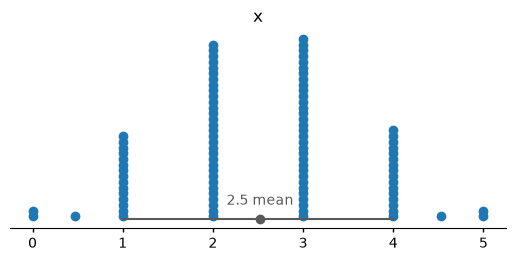

In [13]:
#確率モデルの定義
#-------------------------------------------------------

#インスタンス化
model = pm.Model()

#コンストラクタ
with model:
    x = pm.Binomial('x', p=0.5, n=5) #当たりがでる確率1/2の試行を5回行った場合の当たり回数を返す


#------------------------------------------------------
#サンプリング
#------------------------------------------------------
"""
二項分布に従うサンプルが事前分布として抽出される
"""
#制約条件がある場合`sampel()`を使用
with model:
    prior_samples = pm.sample_prior_predictive(random_seed=42)

#------------------------------------------------------
#NumPy形式でデータを抽出
#------------------------------------------------------
x_samples = az.extract(prior_samples, group='prior').data

value_counts = pd.DataFrame(
    x_samples.reshape(-1)).value_counts().sort_index()

#print(value_counts)

#------------------------------------------------------
#arvizによる分析
#------------------------------------------------------
summary = azs.summary(prior_samples, group='prior', kind='stats')
display(summary) #highest density intervalも表示される

# 3. グラフのプロット（displayは使わず、単体で呼び出す）
#azp.plots_dist()： https://python.arviz.org/projects/plots/en/stable/api/generated/arviz_plots.plot_dist.html
ax = azp.plot_dist(prior_samples, group="prior", var_names='x', kind='dot');

### 参考：正規分布

Sampling: [x]


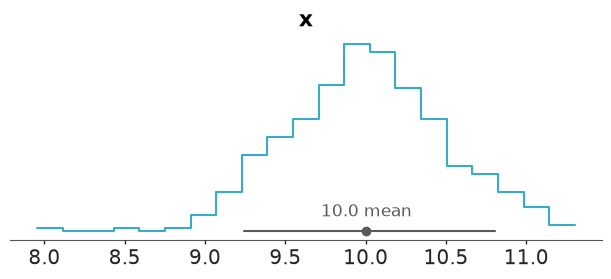

In [34]:
#------------------------------------------------------
#正規分布の作成
#------------------------------------------------------
mu = 10
sigma = 0.5

model4 = pm.Model()
with model4:
    x = pm.Normal('x', mu=mu, sigma=sigma)
    prior_samples4 = pm.sample_prior_predictive(random_seed=42)

x_samples4 = azb.extract(prior_samples4, group='prior').data
ax = azp.plot_dist(prior_samples4, group='prior', kind='hist')
ax.show()

### 参考：β分布

Sampling: [p]


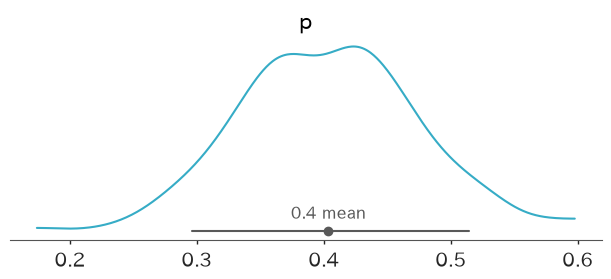

In [13]:
#------------------------------------------------------
#β分布
#確率の尤度を求める関数
#ここでαはアタリ回数、βはハズレ回数を想定
#------------------------------------------------------

from math import gamma
import japanize_matplotlib

alpha = 21
beta = 31

#ベータ関数の定義
def Beta(p, alpha, beta):
    C = gamma(alpha+beta-1)/(gamma(alpha-1)*gamma(beta-1))
    return C * p ** (alpha-1) * (1-p) ** (beta-1)

p = np.arange(0.0, 1.0, 0.01)

# plt.plot(p, Beta(p, alpha, beta))
# plt.title(f'ベータ関数 alpha={alpha} beta={beta}')
# plt.xlabel(r'$p$')
# plt.ylabel('尤度');

#------------------------------------------------------
#PyMCによるモデル定義
#------------------------------------------------------

model5 = pm.Model()
with model5:
    p = pm.Beta('p', alpha=alpha, beta=beta)
    
with model5:
    #サンプリング
    prior_samples5 = pm.sample_prior_predictive(random_seed=42)
    
p_samples5 = azb.extract(prior_samples5, group='prior', num_samples=500).data
#print(p_samples5)

ax = azp.plot_dist(prior_samples5,
                   group='prior',
                   kind='kde',
                   backend='matplotlib')
ax.show()